In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
admissions = pd.read_csv(r"C:\Users\G.Tanuja\Downloads\hospital_admissions.csv")

In [58]:
admissions.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [59]:
admissions = admissions.copy()

# standardize columns
admissions.columns = admissions.columns.str.lower().str.strip().str.replace(" ", "_")

# drop PII & noise
admissions = admissions.drop(
    columns=[
        "name", "doctor", "insurance_provider",
         "room_number"
    ],
    errors="ignore"
)

# clean text columns
text_cols = ["medical_condition", "admission_type", "hospital"]

admissions[text_cols] = admissions[text_cols].apply(
    lambda col: col.str.lower().str.strip()
)

# convert dates
admissions["date_of_admission"] = pd.to_datetime(admissions["date_of_admission"], errors="coerce")
admissions["discharge_date"] = pd.to_datetime(admissions["discharge_date"], errors="coerce")

# length of stay
admissions["length_of_stay"] = (
    admissions["discharge_date"] - admissions["date_of_admission"]
).dt.days

# remove invalid rows
admissions = admissions[admissions["length_of_stay"] >= 0]

# handle missing
admissions = admissions.dropna(
    subset=["medical_condition", "admission_type", "date_of_admission", "discharge_date"]
)


In [60]:
admissions.head()

,age,gender,blood_type,medical_condition,date_of_admission,hospital,billing_amount,admission_type,discharge_date,medication,test_results,length_of_stay
0,30,Male,B-,cancer,2024-01-31,sons and miller,18856.281306,urgent,2024-02-02,Paracetamol,Normal,2
1,62,Male,A+,obesity,2019-08-20,kim inc,33643.327287,emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,76,Female,A-,obesity,2022-09-22,cook plc,27955.096079,emergency,2022-10-07,Aspirin,Normal,15
3,28,Female,O+,diabetes,2020-11-18,"hernandez rogers and vang,",37909.782410,elective,2020-12-18,Ibuprofen,Abnormal,30
4,43,Female,AB+,cancer,2022-09-19,white-white,14238.317814,urgent,2022-10-09,Penicillin,Abnormal,20


In [6]:
from pathlib import Path

Path("cleaned_data").mkdir(parents=True, exist_ok=True)

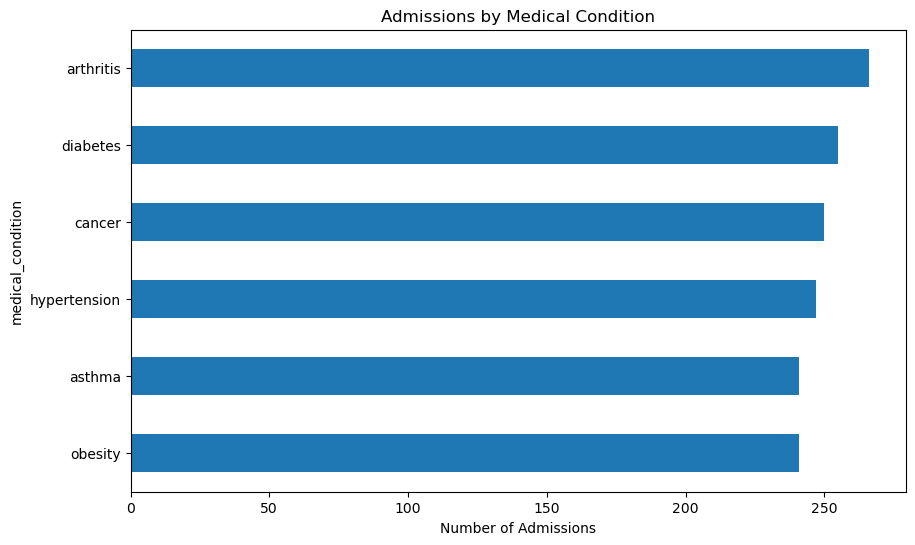

In [9]:
# Admissions by Medical Condition
condition_counts = (
    admissions['medical_condition']
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 6))

condition_counts.plot(
    kind='barh',
    figsize=(10, 6)
)

plt.title('Admissions by Medical Condition')
plt.xlabel('Number of Admissions')
plt.ylabel('medical_condition')

plt.show()

### Observations
* Arthritis — 266
* Diabetes — 255
* Cancer — 250
* Hypertension — 247
* Obesity — 241
* Asthma — 241

### Business Insight:
* Arthritis has the highest admission volume, while admission counts across medical conditions remain relatively balanced.

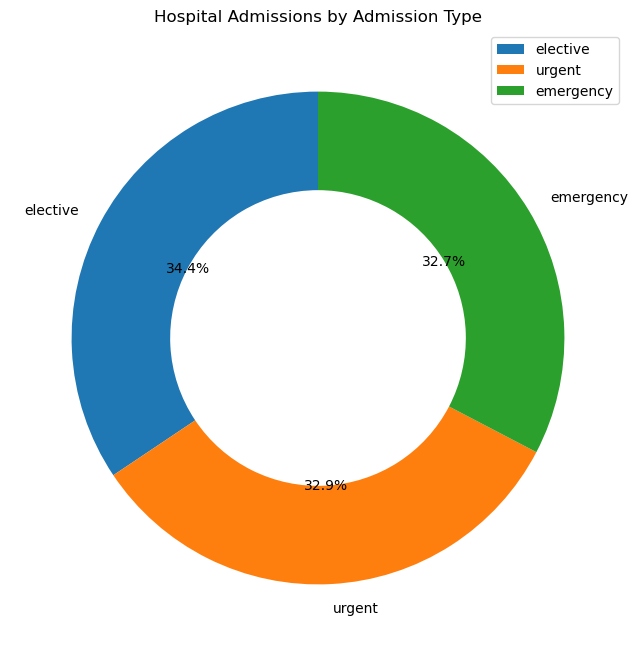

In [12]:
# Admission Type
admission_type = admissions['admission_type'].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    admission_type,
    labels=admission_type.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title('Hospital Admissions by Admission Type')
plt.legend()
plt.show()

### Observation
* Elective admissions have the largest share, followed by urgent and emergency admissions.

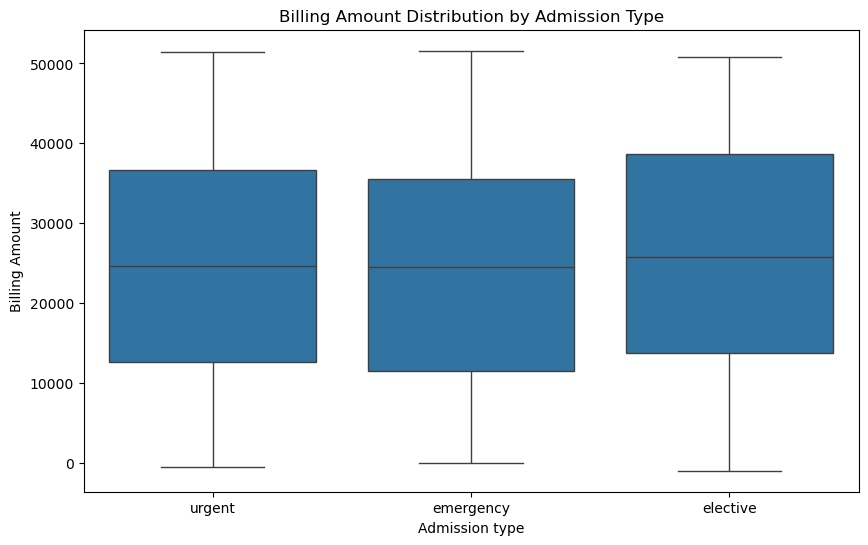

In [19]:
# Billing Amount by Admission Type
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=admissions,
    x='admission_type',
    y='billing_amount'
)

plt.title('Billing Amount Distribution by Admission Type')
plt.xlabel('Admission type')
plt.ylabel('Billing Amount')

plt.show()

### Observations
* median billing
* billing spread
* extreme bills
* potential outliers

### Business Insight
* Billing amounts vary within each admission type, making median and distribution analysis more informative than relying only on average billing.

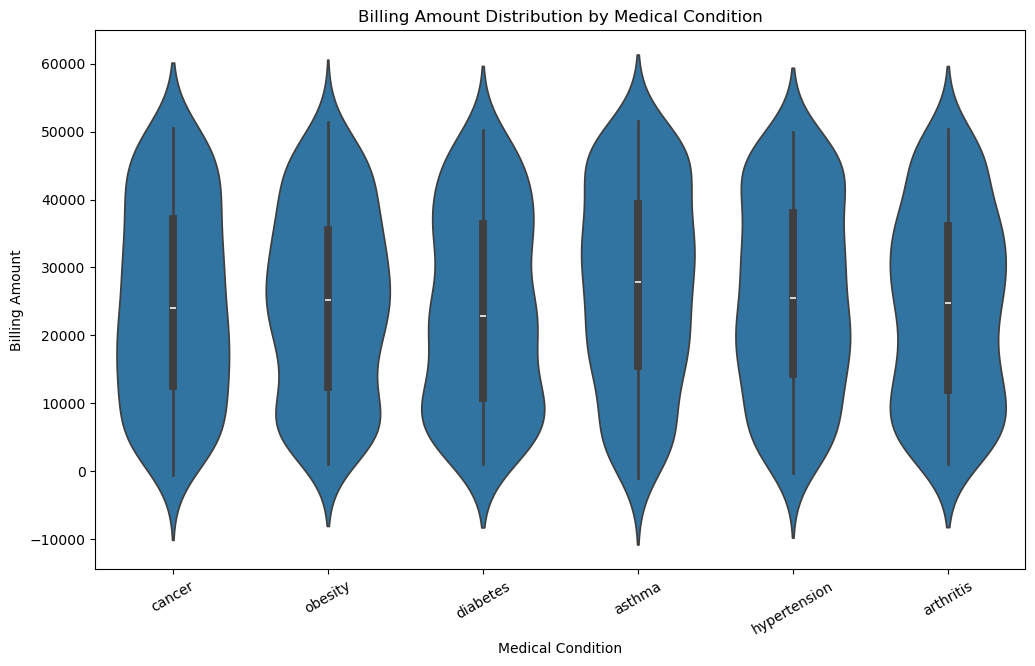

In [21]:
# Billing by Medical Condition
plt.figure(figsize=(12, 7))

sns.violinplot(
    data=admissions,
    x='medical_condition',
    y='billing_amount'
)

plt.title('Billing Amount Distribution by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Billing Amount')

plt.xticks(rotation=30)

plt.show()

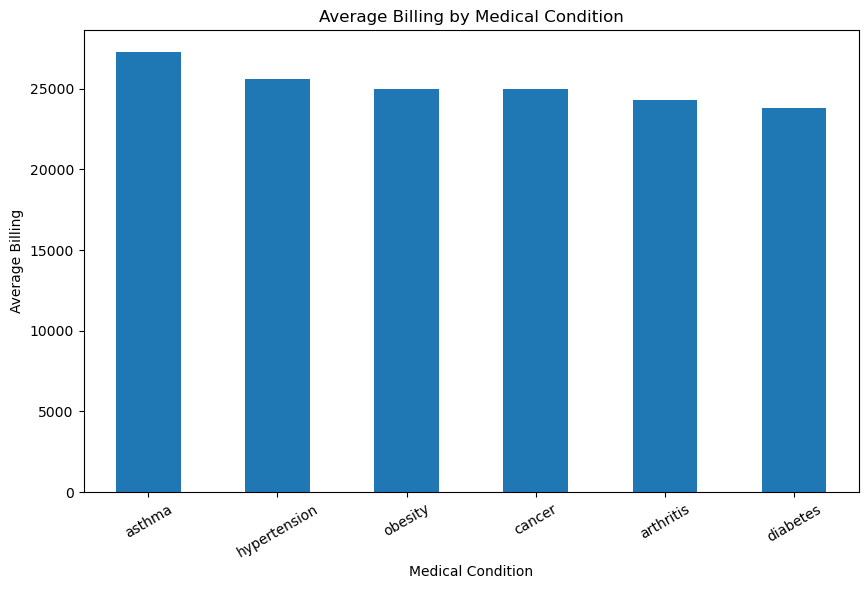

In [22]:
# Average Billing by Medical Condition
avg_billing_condition = (
    admissions
    .groupby('medical_condition')['billing_amount']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

avg_billing_condition.plot(kind='bar')

plt.title('Average Billing by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Average Billing')

plt.xticks(rotation=30)

plt.show()

### Observations
* Comparing average billing across medical conditions can help identify conditions associated with relatively higher treatment costs.

In [38]:
print(admissions.columns.tolist())

['age', 'gender', 'blood_type', 'medical_condition', 'date_of_admission', 'hospital', 'billing_amount', 'admission_type', 'discharge_date', 'length_of_stay']


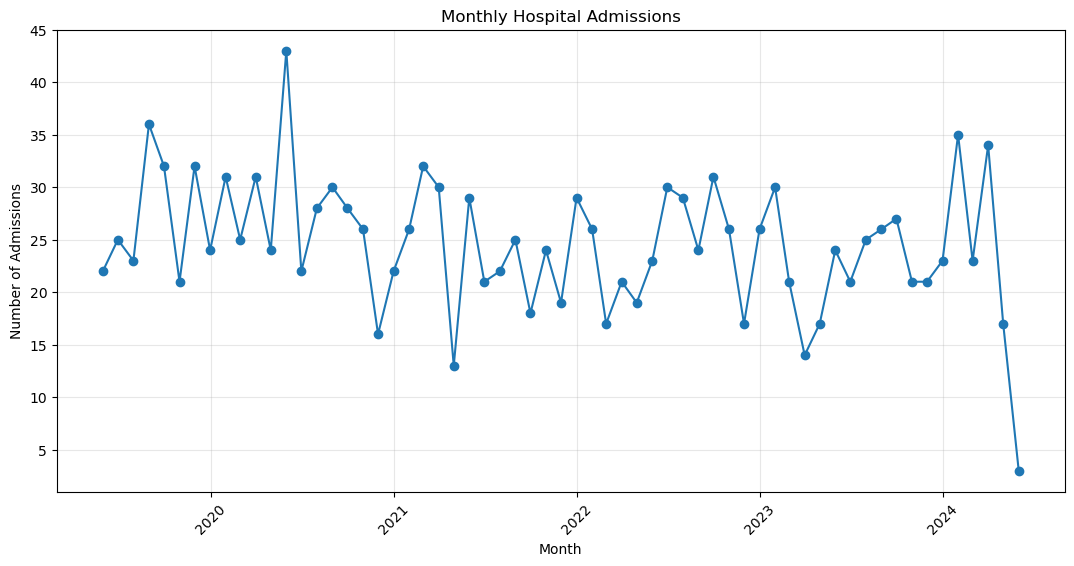

In [26]:
monthly_admissions = (
    admissions
    .set_index('date_of_admission')
    .resample('ME')
    .size()
)

plt.figure(figsize=(13, 6))

plt.plot(
    monthly_admissions.index,
    monthly_admissions.values,
    marker='o'
)

plt.title('Monthly Hospital Admissions')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

### Business Insight
* Monthly admission trends can help identify periods of higher patient demand and support staffing and capacity planning.

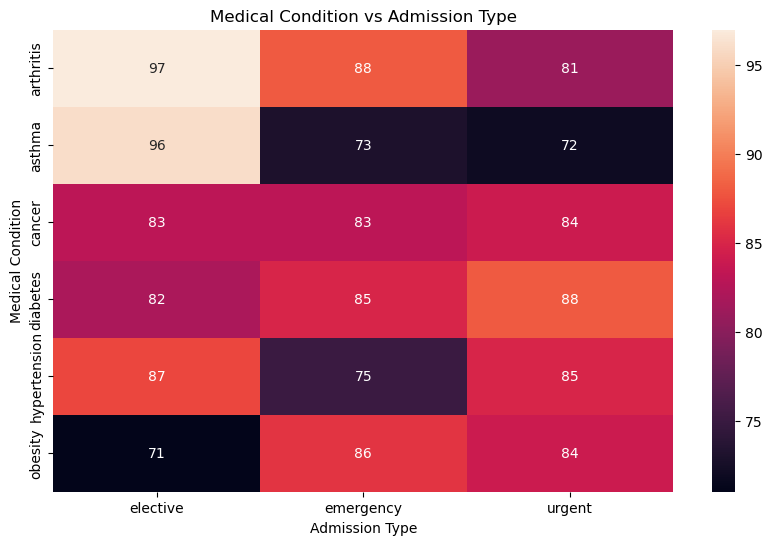

In [27]:
# Medical Condition vs Admission Type
condition_admission = pd.crosstab(
    admissions['medical_condition'],
    admissions['admission_type']
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    condition_admission,
    annot=True,
    fmt='d'
)

plt.title('Medical Condition vs Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Medical Condition')

plt.show()

### Observations
* emergency admissions
* urgent admissions
* elective admissions

### Business insight:

* The heatmap helps hospital management understand how different medical conditions contribute to different admission pathways.

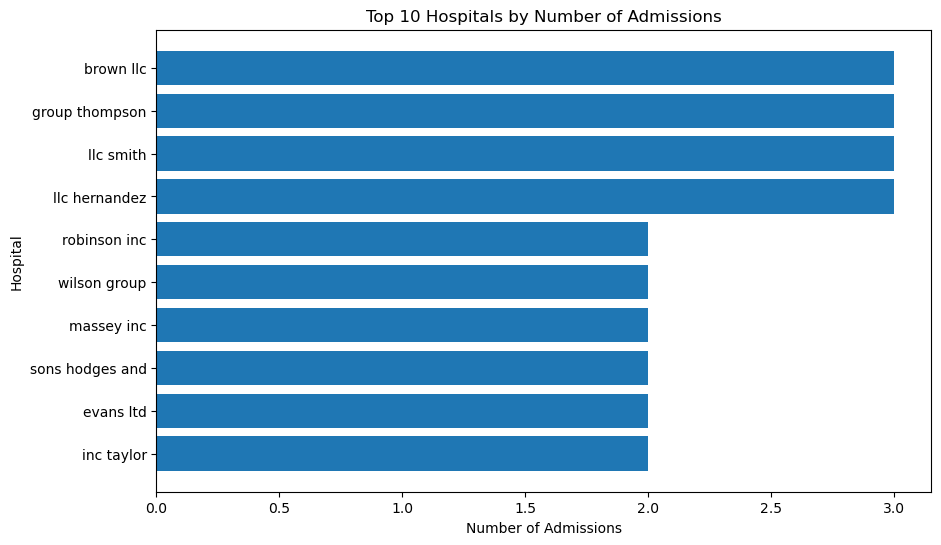

In [31]:
# Hospital-wise Admissions
hospital_counts = admissions['hospital'].value_counts().head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    hospital_counts.index[::-1],
    hospital_counts.values[::-1]
)

plt.title('Top 10 Hospitals by Number of Admissions')
plt.xlabel('Number of Admissions')
plt.ylabel('Hospital')

plt.show()

### Observation
* The chart identifies the hospitals with the highest patient admission volumes, helping management understand where patient demand is concentrated.

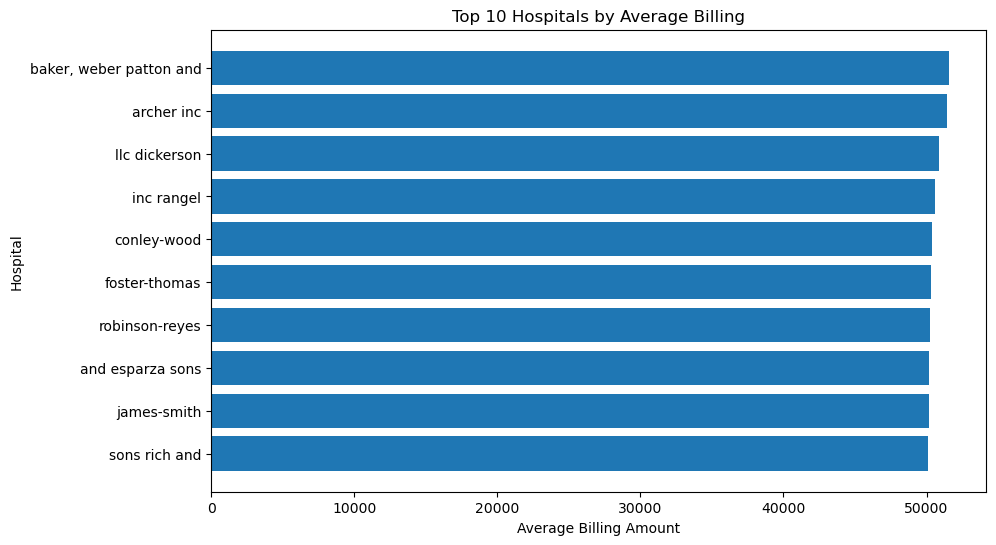

In [32]:
hospital_billing = (
    admissions
    .groupby('hospital')['billing_amount']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    hospital_billing.index[::-1],
    hospital_billing.values[::-1]
)

plt.title('Top 10 Hospitals by Average Billing')
plt.xlabel('Average Billing Amount')
plt.ylabel('Hospital')

plt.show()

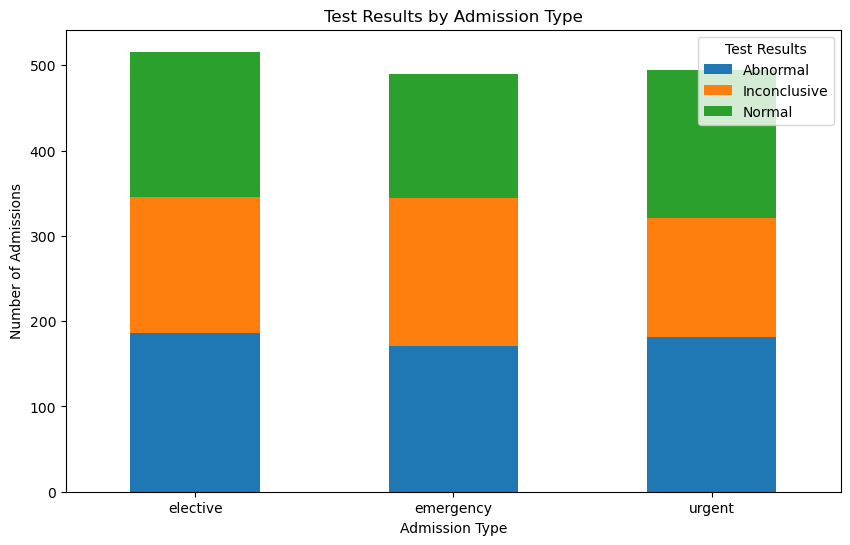

In [51]:
# Test Results by Admission Type
test_admission = pd.crosstab(
    admissions['admission_type'],
    admissions['test_results']
)

test_admission.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Test Results by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Number of Admissions')

plt.xticks(rotation=0)
plt.legend(title='Test Results')

plt.show()

### Business Insight
* This visualization compares the diagnostic outcome mix across elective, urgent, and emergency admissions.

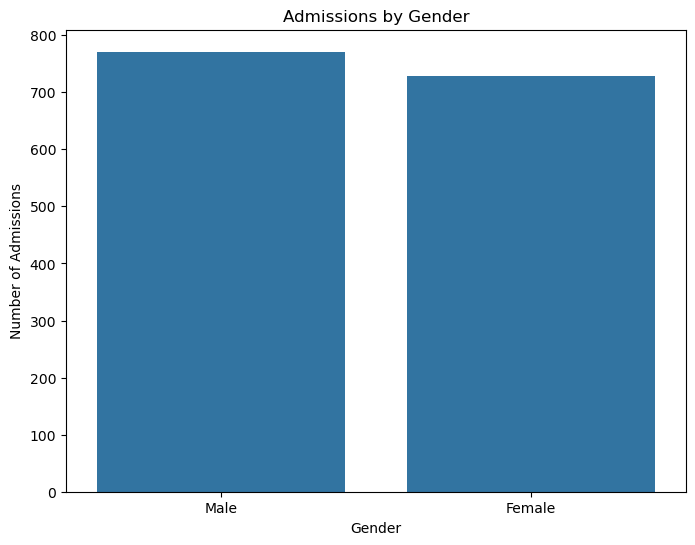

In [52]:
# Gender Distribution
plt.figure(figsize=(8, 6))

sns.countplot(
    data=admissions,
    x='gender'
)

plt.title('Admissions by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Admissions')

plt.show()

### Observations
* Observation
* Male admissions: 771
* Female admissions: 729

### Business insight:
* Admissions are relatively balanced by gender, with a slightly higher number of male admissions.

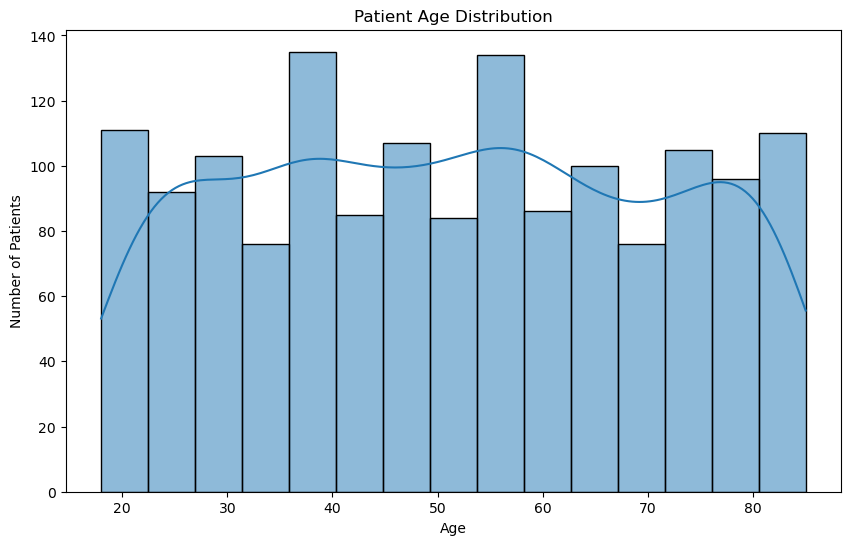

In [53]:
# Patient Age Distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data=admissions,
    x='age',
    bins=15,
    kde=True
)

plt.title('Patient Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Patients')

plt.show()

### Observation
* Average age is approximately 51 years
* Patients range from 18 to 85 years

### Business insight:
* The hospital serves a broad adult population, with substantial representation across middle-aged and older patients.

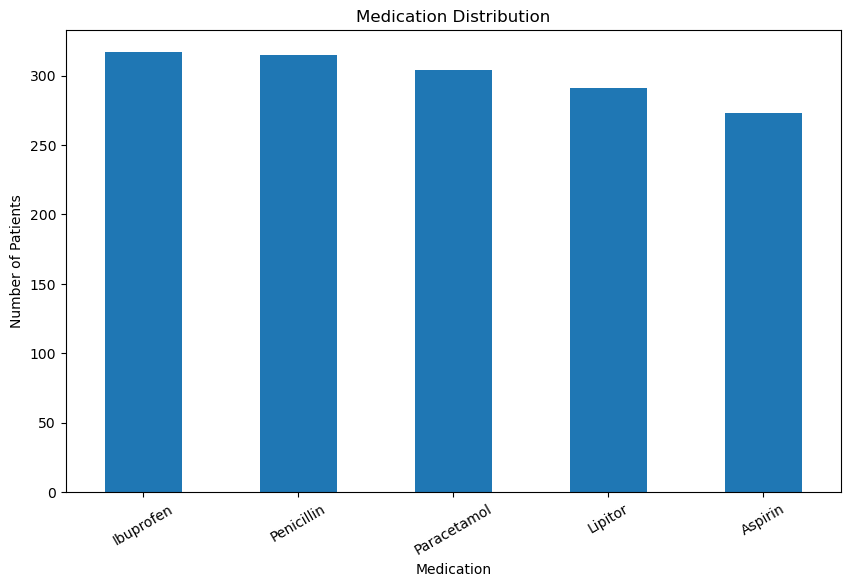

In [61]:
# Medication Usage
medication_counts = (
    admissions['medication']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

medication_counts.plot(kind='bar')

plt.title('Medication Distribution')
plt.xlabel('Medication')
plt.ylabel('Number of Patients')

plt.xticks(rotation=30)

plt.show()

### Business Insight
* Medication utilization provides an overview of treatment patterns and can support inventory and pharmacy planning.